In [1]:
# want to combine com and noncom cases into one workflow
# compare different values of a, define all lengths in terms of horizon radius
# will need to make two separate python scripts with the functions i will need to generate plots

In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import shockFunc260331 as sf
import NCShockFunc260331 as nsf

In [3]:
num = 1000
sf.num = num
nsf.num = num

eps = 0.0001
sf.r0min = eps
nsf.eps = eps

R = 1

In [4]:
r0grid = np.linspace(eps,R-eps,num)

calphagrid = sf.alpha(r0grid,R)
ncalphagrid = nsf.alpha(r0grid,R)

cmask = sf.k3(r0grid,R) > 0
ncmask = nsf.k3(r0grid,R) != 0

[]

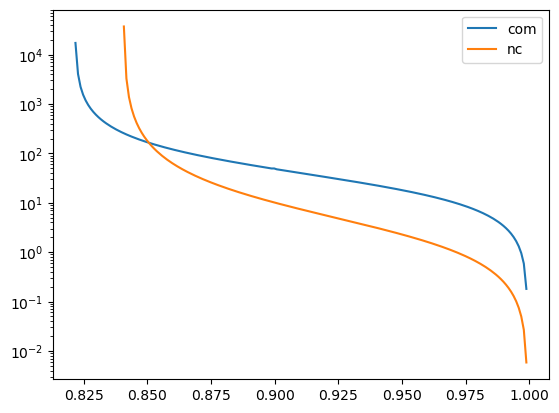

In [5]:
plt.plot(r0grid[cmask],calphagrid[cmask],label='com')
plt.plot(r0grid[ncmask],ncalphagrid[ncmask],label='nc')
plt.legend()
plt.semilogy()

In [6]:
normcalphagrid = calphagrid[cmask]/calphagrid[cmask].max()
normncalphagrid = ncalphagrid[ncmask]/ncalphagrid[ncmask].max()

[]

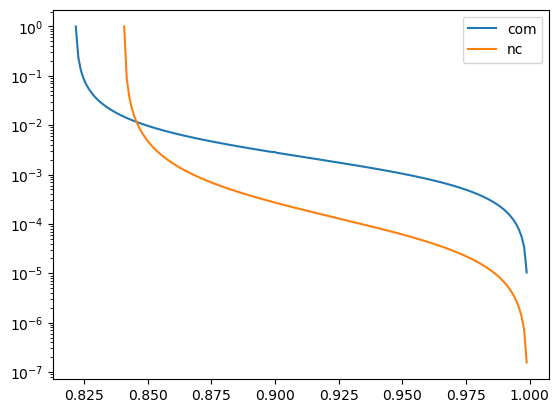

In [7]:
plt.plot(r0grid[cmask],normcalphagrid,label='com')
plt.plot(r0grid[ncmask],normncalphagrid,label='nc')
plt.legend()
plt.semilogy()

In [8]:
careaInt = sf.shockArea(r0grid,R)
ncareaInt = nsf.shockArea(r0grid,R)

cmask = careaInt > 0
ncmask = ncareaInt > 0

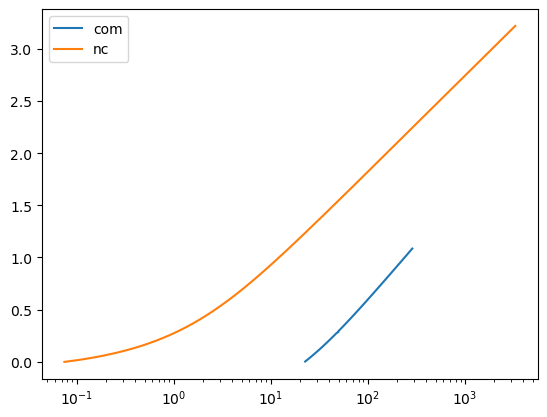

In [9]:
plt.plot(calphagrid[cmask],careaInt[cmask],label='com')
plt.plot(ncalphagrid[ncmask],ncareaInt[ncmask],label='nc')
plt.semilogx()
# plt.semilogy()
plt.legend()

In [10]:
rminarr = np.logspace(np.log10(R+eps),np.log10(min([sf.rmax,nsf.rmax])),num)

cLvsrminarr = sf.Lvsrmin(rminarr,R)
ncLvsrminarr = nsf.Lvsrmin(rminarr,R,0.1)
ncLvsrminarr2 = nsf.Lvsrmin(rminarr,R,0.05)
ncLvsrminarr3 = nsf.Lvsrmin(rminarr,R,0.2)

d:\HoloProj\NCShockFunc260331.py:133: RuntimeWarning: divide by zero encountered in divide
  integ = 2/np.sqrt((rarr**4) * f(rarr,R) * h(rarr,a) * b(rarr,rmin))


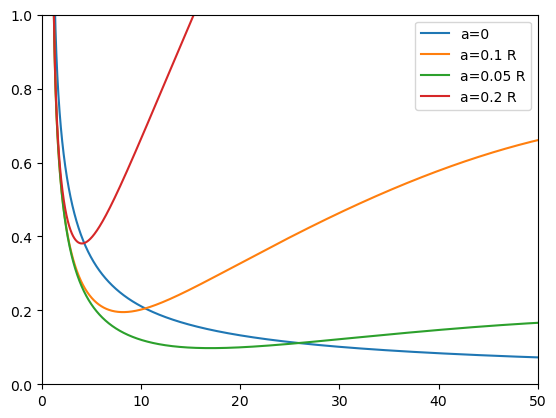

In [11]:
plt.plot(rminarr,cLvsrminarr,label='a=0')
plt.plot(rminarr,ncLvsrminarr,label='a=0.1 R')
plt.plot(rminarr,ncLvsrminarr2,label='a=0.05 R')
plt.plot(rminarr,ncLvsrminarr3,label='a=0.2 R')
plt.xlim((0,rminarr.max()/2))
plt.ylim((0,1))
plt.legend()

In [12]:
adjrminarr = nsf.rMinCutoff(rminarr,ncLvsrminarr)
adjrminarr2 = nsf.rMinCutoff(rminarr,ncLvsrminarr2)
adjrminarr3 = nsf.rMinCutoff(rminarr,ncLvsrminarr3)

In [13]:
adjncLvsrminarr = nsf.Lvsrmin(adjrminarr,R,0.1)
adjncLvsrminarr2 = nsf.Lvsrmin(adjrminarr,R,0.05)
adjncLvsrminarr3 = nsf.Lvsrmin(adjrminarr,R,0.2)

In [14]:
cunArea = sf.unAreaInt(rminarr,R)
ncunArea = nsf.unAreaInt(adjrminarr,R,0.1)
ncunArea2 = nsf.unAreaInt(adjrminarr2,R,0.05)
ncunArea3 = nsf.unAreaInt(adjrminarr3,R,0.2)

(0.0, 4.0)

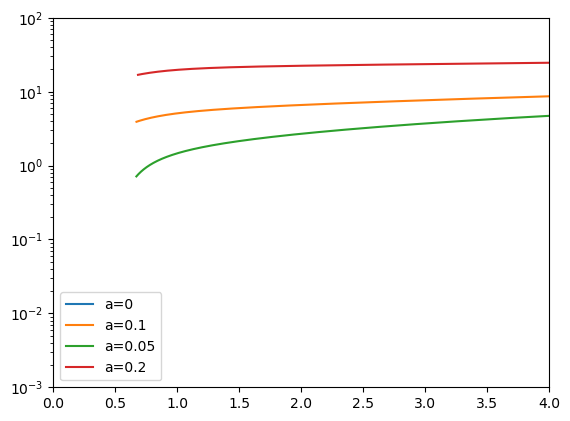

In [15]:
plt.plot(cLvsrminarr,cunArea,label='a=0')
plt.plot(adjncLvsrminarr,ncunArea,label='a=0.1')
plt.plot(adjncLvsrminarr2,ncunArea2,label='a=0.05')
plt.plot(adjncLvsrminarr3,ncunArea3,label='a=0.2')
plt.legend()
plt.semilogy()
plt.ylim((0.001,100))
plt.xlim((0,4))

In [16]:
cunArea

array([-5.51423207e+15, -1.32633610e+17, -2.59801533e+17, -3.87018028e+17,
       -5.14283123e+17, -6.41596845e+17, -7.68959223e+17, -8.96370282e+17,
       -1.02383005e+18, -1.15133856e+18, -1.27889583e+18, -1.40650190e+18,
       -1.53415679e+18, -1.66186053e+18, -1.78961314e+18, -1.91741466e+18,
       -2.04526511e+18, -2.17316452e+18, -2.30111292e+18, -2.42911034e+18,
       -2.55715680e+18, -2.68525233e+18, -2.81339696e+18, -2.94159072e+18,
       -3.06983363e+18, -3.19812573e+18, -3.32646704e+18, -3.45485759e+18,
       -3.58329741e+18, -3.71178653e+18, -3.84032497e+18, -3.96891276e+18,
       -4.09754993e+18, -4.22623651e+18, -4.35497253e+18, -4.48375802e+18,
       -4.61259300e+18, -4.74147750e+18, -4.87041155e+18, -4.99939518e+18,
       -5.12842841e+18, -5.25751129e+18, -5.38664382e+18, -5.51582605e+18,
       -5.64505800e+18, -5.77433970e+18, -5.90367118e+18, -6.03305246e+18,
       -6.16248358e+18, -6.29196456e+18, -6.42149544e+18, -6.55107623e+18,
       -6.68070698e+18, -

(0.5, 4.0)

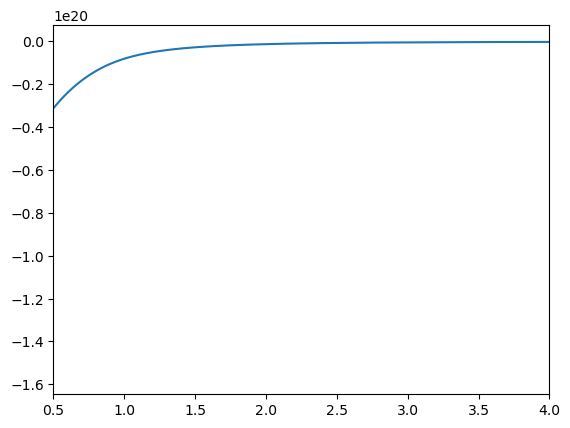

In [17]:
plt.plot(cLvsrminarr,cunArea,label='a=0')
plt.xlim((0.5,4))
# plt.semilogy()